In [1]:
import numpy as np
import pandas as pd
import uproot
from pathlib import Path

import matplotlib.pyplot as plt
from mutools.plotting import use_style
from mutools.plotting.helpers import mark_axis

use_style('rootlike')

PATH = Path('/Users/mueller/data/spineosc')

# File to open for the 'sim' (MC) sample per detector/run.
DETECTOR_FILES = {
    'sbnd':        'v1.0.10/spineosc_numu_sbnd_v1.0.10_nosyst.root',
    'icarus_run2': 'v1.0.10/spineosc_numu_icarus_run2_v1.0.10_nosyst.root',
    'icarus_run4': 'v1.0.10/spineosc_numu_icarus_run4_v1.0.10_nosyst.root',
}
DETECTOR_KEYS = {
    'sbnd': 'sbnd',
    'icarus_run2': 'icarus_run2',
    'icarus_run4': 'icarus_run4',
}

# Trigger-emulation PE-to-threshold calibration, its +/-1 sigma
# uncertainty, and the PE-equivalent threshold itself -- detector/run
# specific, supplied directly (not derivable from the ntuples).
TRIGGER_CONFIG = {
    'sbnd': {'scale': 0.647, 'sigma': 0.004, 'threshold': 2000},
    'icarus_run2': {'scale': 0.615, 'sigma': 0.018, 'threshold': 6000},
    'icarus_run4': {'scale': 0.361, 'sigma': 0.013, 'threshold': 3000},
}

DETECTOR_LABELS = {
    'sbnd': r'$\bf{SBND}$',
    'icarus_run2': r'$\bf{ICARUS}$ Run 2',
    'icarus_run4': r'$\bf{ICARUS}$ Run 4',
}
DETECTOR_TITLES = {
    'sbnd': 'SBND Simulation',
    'icarus_run2': 'ICARUS Run 2 Simulation',
    'icarus_run4': 'ICARUS Run 4 Simulation',
}

SAVEPATH = Path('/Users/mueller/Projects/spineosc_technote/figures')
SAVEPATH.mkdir(parents=True, exist_ok=True)

In [2]:
signal = {}

for detector, filename in DETECTOR_FILES.items():
    rf = uproot.open(PATH / filename)
    key = DETECTOR_KEYS[detector]
    signal[detector] = rf[f'events/{key}/signal'].arrays(library='pd')
    print(f"{detector}: signal events = {len(signal[detector])}")

sbnd: signal events = 573160
icarus_run2: signal events = 141395
icarus_run4: signal events = 234033


In [3]:
# Signal definition -- true_category 0 (CCQE-like, 1p) or 2 (n-proton),
# matching handcrafted.ipynb. The `signal` tree is already restricted to
# these two categories, so this mask is a no-op there, but kept explicit
# in case it's ever applied to a broader table.
apply_signal_tpc = lambda df: (df['true_fiducialize_cathode'] == 1)
apply_signal_ccqe = lambda df: (df['true_category'] == 0) & apply_signal_tpc(df)
apply_signal_nproton = lambda df: (df['true_category'] == 2) & apply_signal_tpc(df)
apply_signal = lambda df: apply_signal_ccqe(df) | apply_signal_nproton(df)

# TPC Preselection -- this project's established base-selection cut
# (matches select_full_dent in detvar.ipynb/trigger.ipynb), replacing
# handcrafted.ipynb's reco_fiducial_cut + reco_containment_cut (neither
# exists in this schema).
apply_tpc_cut = lambda df: (df['reco_fiducialize_cathode'] == 1) & (df['reco_fiducial_cut_osc']) & (df['reco_user_containment_cut'] == 1)

apply_shower_multiplicity = lambda df: (df['reco_photon_multiplicity'] == 0) & (df['reco_electron_multiplicity'] == 0)
apply_pion_multiplicity = lambda df: (df['reco_pion_multiplicity'] == 0)
apply_proton_multiplicity_1p = lambda df: (df['reco_proton_multiplicity'] == 1)
apply_proton_multiplicity_multip = lambda df: (df['reco_proton_multiplicity'] > 1)
apply_proton_multiplicity = lambda df: apply_proton_multiplicity_1p(df) | apply_proton_multiplicity_multip(df)
apply_muon_cut = lambda df: (df['reco_muon_multiplicity'] == 1)

In [4]:
from scipy.stats import beta


def equal_population_edges(
    values: pd.Series,
    lo: float,
    hi: float,
    nbins: int
) -> np.ndarray:
    """
    Bin edges that place an equal number of parent-population entries in
    each bin.

    The parent population is the denominator of the efficiency (the
    signal sample), so each point carries comparable statistics and the
    error bars come out roughly uniform. Edges are the quantiles of that
    distribution inside [lo, hi], with the outer edges pinned to the
    requested range.

    Parameters
    ----------
    values : pd.Series
        The parent-population values to derive the binning from.
    lo, hi : float
        The range to bin over. Entries outside it are ignored.
    nbins : int
        The number of bins requested.

    Returns
    -------
    np.ndarray
        The bin edges (size nbins + 1, or fewer if the distribution is
        too concentrated to support that many distinct quantiles).
    """
    v = np.asarray(values, dtype=float)
    v = v[np.isfinite(v) & (v >= lo) & (v <= hi)]
    if v.size == 0:
        raise ValueError(f'no parent-population entries in [{lo}, {hi}]')
    edges = np.quantile(v, np.linspace(0.0, 1.0, nbins + 1))
    edges[0], edges[-1] = lo, hi

    # A spiked distribution can repeat a quantile; duplicate edges would
    # make empty bins, so collapse them and say so.
    unique = np.unique(edges)
    if unique.size < edges.size:
        print(f'  note: {edges.size - unique.size} duplicate quantile edge(s) '
              f'collapsed; using {unique.size - 1} bins instead of {nbins}')
    return unique


def make_counts(
    energy: pd.Series,
    mask0: pd.Series,
    mask1: pd.Series,
    edges: np.ndarray
) -> tuple:
    """
    Bin the energy variable for the two provided masks and return the
    raw counts, which the efficiency and its uncertainty are built from.

    Parameters
    ----------
    energy : pd.Series
        The variable to be binned.
    mask0 : pd.Series
        The denominator mask (the signal sample).
    mask1 : pd.Series
        The numerator mask (signal passing the cuts so far).
    edges : np.ndarray
        The edges to be used for binning the energy variable.

    Returns
    -------
    tuple[np.ndarray, np.ndarray]
        The per-bin numerator (passed) and denominator (total) counts.
    """
    total, _ = np.histogram(energy[mask0], bins=edges)
    passed, _ = np.histogram(energy[mask1], bins=edges)
    return passed, total


def efficiency_errors(
    passed: np.ndarray,
    total: np.ndarray,
    method: str = 'clopper-pearson',
    level: float = 0.6827
) -> tuple:
    """
    Per-bin efficiency and its statistical uncertainty.

    The numerator is a subset of the denominator, so the bin content is
    binomial rather than two independent Poisson counts: the uncertainty
    is that of a ratio of correlated counts, sqrt(eff(1-eff)/total) in
    the normal approximation.

    'clopper-pearson' (the default) is the exact binomial interval, and
    is what ROOT's TEfficiency uses by default. It is asymmetric and
    stays inside [0, 1], which matters here because the later cut stages
    reach efficiencies close to 1, where the normal approximation
    returns an error of zero.

    Parameters
    ----------
    passed : np.ndarray
        Per-bin numerator counts.
    total : np.ndarray
        Per-bin denominator counts.
    method : str
        'clopper-pearson' or 'normal'.
    level : float
        Coverage of the interval. Default is 0.6827, i.e. one sigma.

    Returns
    -------
    tuple[np.ndarray, np.ndarray]
        The efficiency per bin (NaN where the denominator is empty), and
        a (2, nbins) array of lower/upper errors for ax.errorbar.
    """
    passed = np.asarray(passed, dtype=float)
    total = np.asarray(total, dtype=float)
    filled = total > 0
    eff = np.full(total.shape, np.nan)
    np.divide(passed, total, out=eff, where=filled)

    if method == 'normal':
        err = np.full(total.shape, np.nan)
        np.divide(eff * (1.0 - eff), total, out=err, where=filled)
        err = np.sqrt(err)
        return eff, np.vstack([err, err])

    if method != 'clopper-pearson':
        raise ValueError(f'unsupported method: {method!r}')

    alpha = 1.0 - level
    # beta.ppf returns NaN at the boundaries (passed == 0 or == total),
    # where the interval is one-sided: 0 and 1 respectively.
    low = beta.ppf(alpha / 2.0, passed, total - passed + 1.0)
    high = beta.ppf(1.0 - alpha / 2.0, passed + 1.0, total - passed)
    low = np.where(np.isnan(low), 0.0, low)
    high = np.where(np.isnan(high), 1.0, high)
    return eff, np.vstack([eff - low, high - eff])


def add_efficiency(
    ax: plt.Axes,
    passed: np.ndarray,
    total: np.ndarray,
    edges: np.ndarray,
    label: str = None,
    color: str = None,
    method: str = 'clopper-pearson',
    integrated: float = None
) -> None:
    """
    Draw one efficiency curve as points with statistical error bars, the
    x error spanning each bin.

    The legend carries the integrated efficiency. Pass it in via
    `integrated` to quote the whole sample: computing it from the binned
    counts instead would cover only the plotted range, so the same cut
    would report a different number on every plot. Falls back to the
    binned counts when not supplied.
    """
    eff, yerr = efficiency_errors(passed, total, method=method)
    if integrated is None:
        integrated = passed.sum() / total.sum() if total.sum() else np.nan
    centers = 0.5 * (edges[:-1] + edges[1:])

    ax.errorbar(
        centers,
        eff,
        xerr=0.5 * np.diff(edges),
        yerr=yerr,
        fmt='o',
        markersize=4,
        linewidth=1.0,
        capsize=0,
        label=f'{label} ({integrated:.1%})',
        color=color
    )


def build_efficiency_plot(
    df: pd.DataFrame,
    apply_signal: callable,
    apply_pcut: callable,
    edges: np.ndarray,
    var_key: str = 'true_neutrino_energy',
    xlabel: str = 'True Neutrino Energy [GeV]',
    detector_label: str = None,
    channel_label: str = None,
    mark_fs: str = None,
    binning: str = 'fixed',
    nbins: int = None,
    error_method: str = 'clopper-pearson',
    savefig: str = None
) -> None:
    """
    Cut-by-cut efficiency versus `var_key`, with binomial error bars.

    Parameters
    ----------
    binning : str
        'fixed' (default) uses `edges` as given. 'equal-population'
        keeps only the range [edges[0], edges[-1]] and rebins it so each
        bin holds the same number of signal events, so an existing call
        switches mode by adding this argument alone.
    nbins : int
        Number of bins for 'equal-population'. Defaults to the number
        implied by `edges`.
    error_method : str
        Passed to efficiency_errors: 'clopper-pearson' or 'normal'.
    """
    figure, ax = plt.subplots(figsize=(8, 6))
    energy = df[var_key]

    # Signal mask -- also the parent population for equal-population binning.
    mask_signal = apply_signal(df)

    edges = np.asarray(edges, dtype=float)
    if binning == 'equal-population':
        edges = equal_population_edges(
            energy[mask_signal], edges[0], edges[-1],
            len(edges) - 1 if nbins is None else nbins
        )
    elif binning != 'fixed':
        raise ValueError(f'unsupported binning: {binning!r}')

    # Initialize selection to all True, then apply cuts sequentially
    selection = np.repeat(True, len(df))

    # Cuts
    cuts = {
        'TPC Preselection': apply_tpc_cut,
        'Shower Veto': apply_shower_multiplicity,
        'Pion Veto': apply_pion_multiplicity,
        'Proton Requirements': apply_pcut,
        'Muon Requirements': apply_muon_cut
    }

    # Apply cuts sequentially and plot efficiency after each cut
    n_signal = int(np.count_nonzero(mask_signal))
    for cut_name, cut_func in cuts.items():
        selection &= cut_func(df)
        passed, total = make_counts(energy, mask_signal, mask_signal & selection, edges)
        # Integrated over the WHOLE signal sample, not the plotted range and
        # not restricted to events where `var_key` is defined, so the number
        # quoted for a given cut is the same on every plot.
        integrated = np.count_nonzero(mask_signal & selection) / n_signal if n_signal else np.nan
        add_efficiency(ax, passed, total, edges, label=cut_name,
                       method=error_method, integrated=integrated)

    # Finalize plot
    ax.set_xlim(edges[0], edges[-1])
    ax.set_ylim(0, 1)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Efficiency')
    mark_axis(ax, r'$\bf{SBN}$ Analysis-in-Progress')
    if mark_fs:
        mark_axis(ax, mark_fs, alignment='right')

    # Set legend title
    legend = ax.legend()
    title = detector_label if channel_label is None else f"{detector_label}\n{channel_label}"
    legend.set_title(title)
    legend.get_title().set_fontweight("bold")
    legend.get_title().set_fontsize(14)
    legend.get_title().set_color("#d67a11")

    # Save figure if requested
    if savefig is not None:
        figure.savefig(savefig)


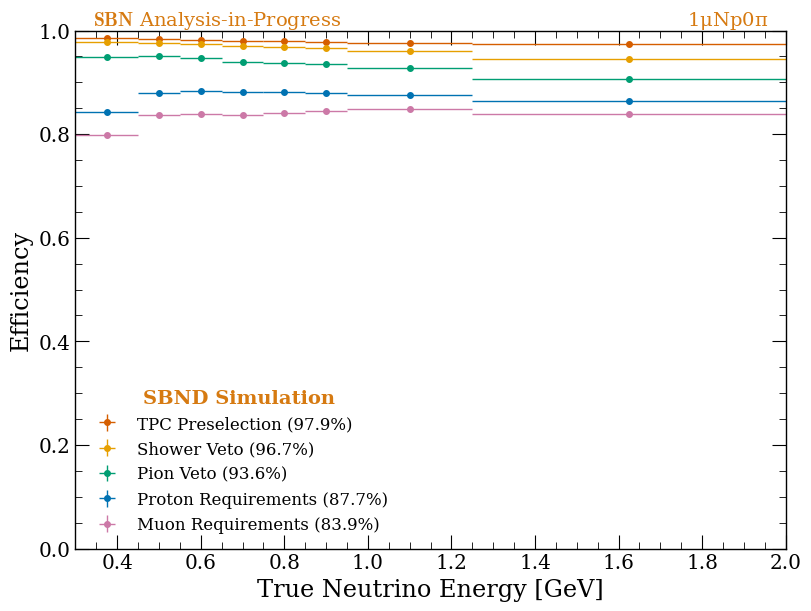

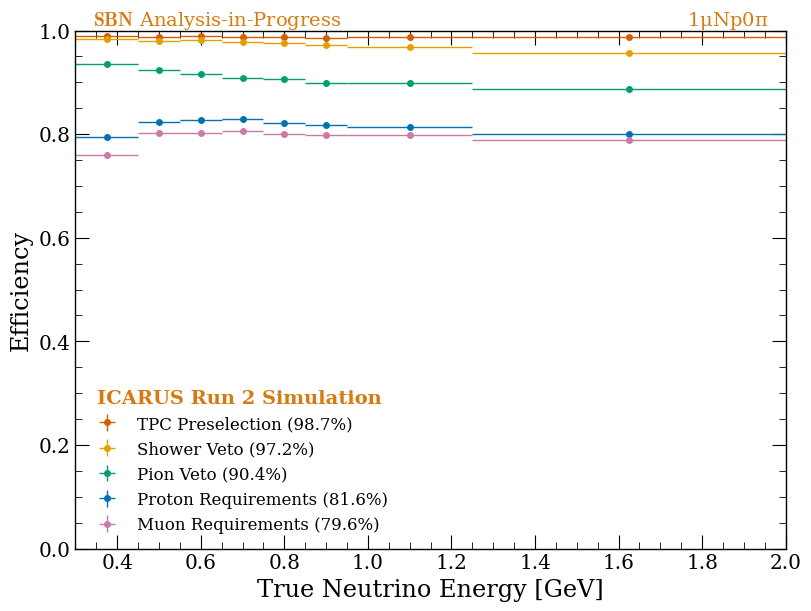

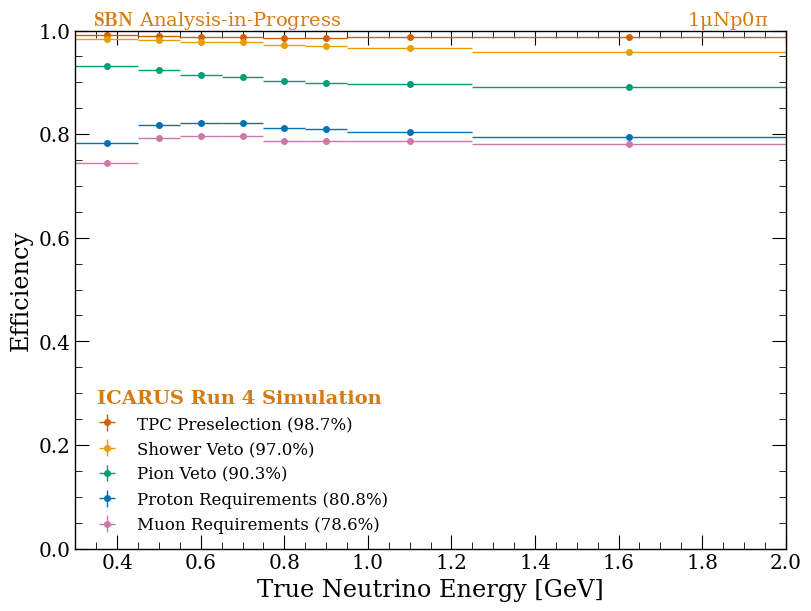

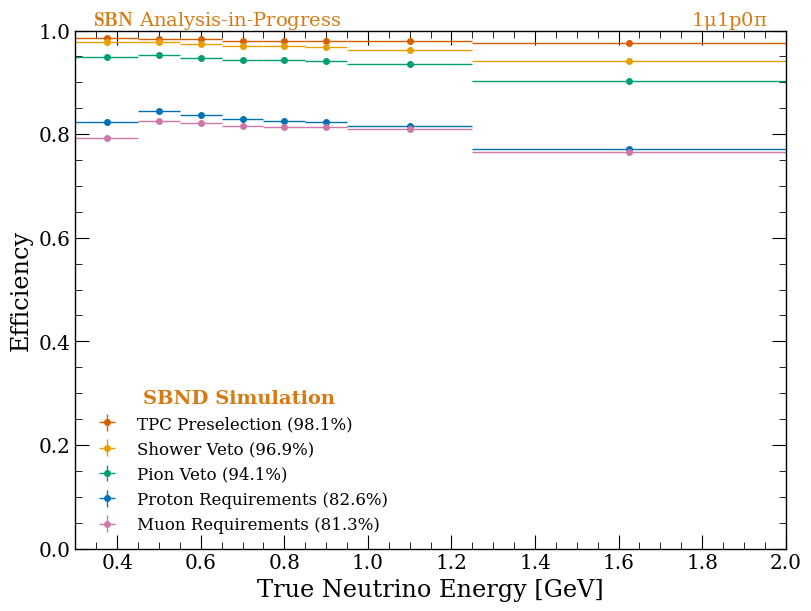

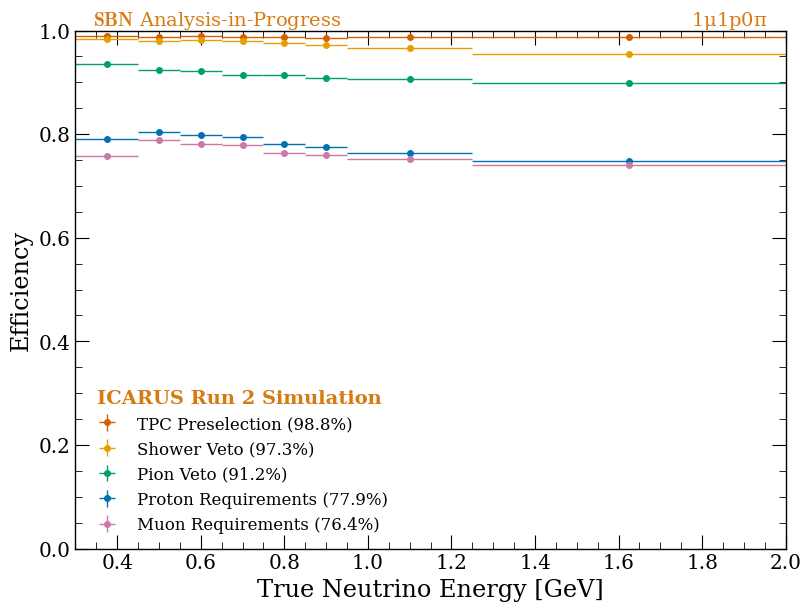

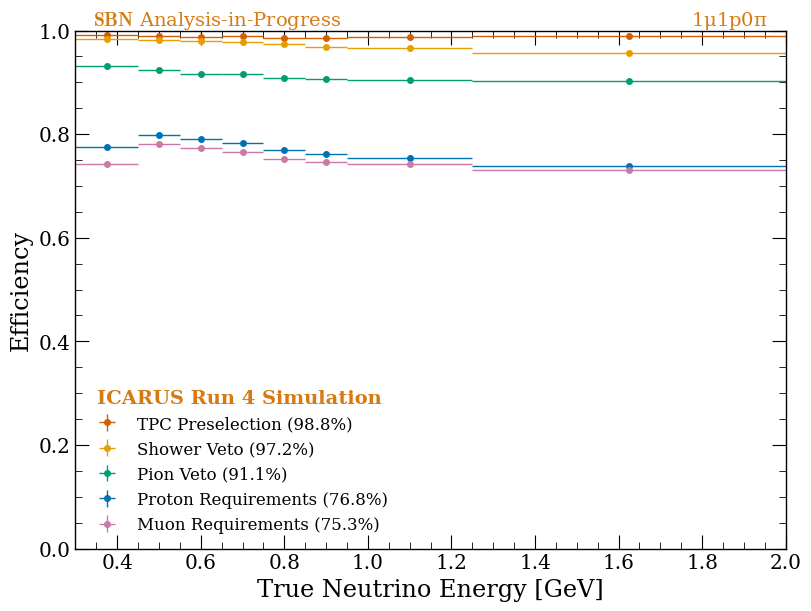

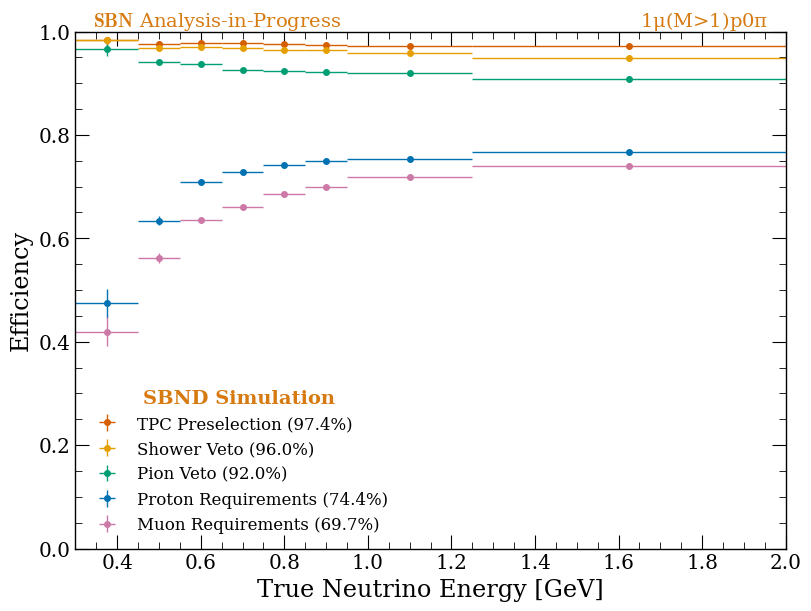

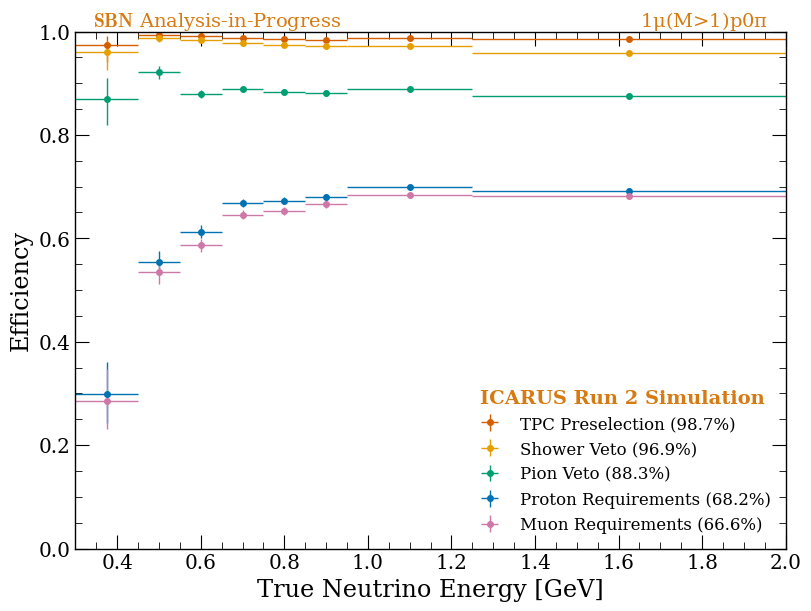

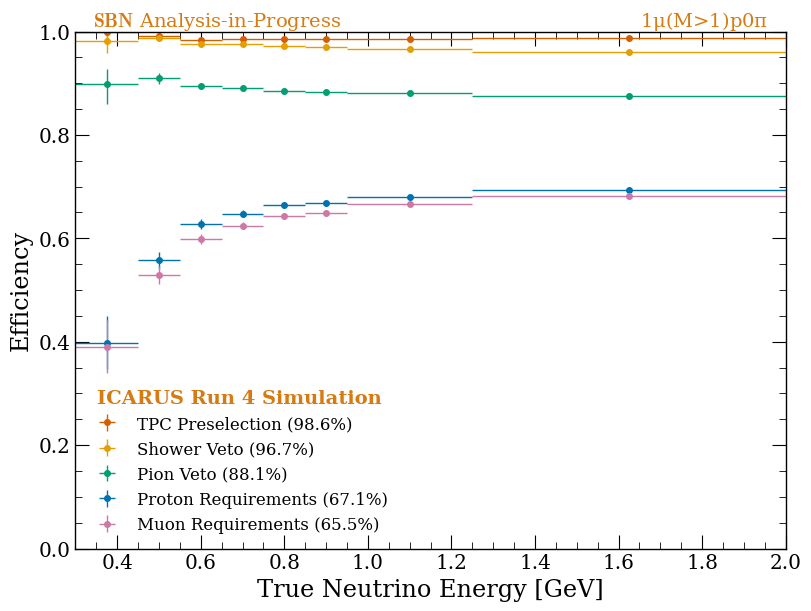

In [12]:
# Matches this project's established reco/true energy edges (trigger.ipynb),
# which are also identical to the external vars.toml's `true_energy` variable.
# handcrafted.ipynb further halves the resolution for the efficiency plot
# specifically (edges[::2]), presumably for per-bin statistics.
edges = np.array([0.3, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0, 1.25, 1.5, 2.0])
edges_efficiency = edges[::2]

# Only the currently-active configuration in handcrafted.ipynb: a single
# inclusive channel (any proton multiplicity >= 1), not the disabled
# single-proton/multi-proton split. Detector identity goes into the legend
# title (via detector_label), matching handcrafted.ipynb -- not a second
# mark_axis call, which would collide with the "Analysis-in-Progress"
# watermark build_efficiency_plot already places top-left.
for detector in DETECTOR_FILES:
    build_efficiency_plot(
        signal[detector],
        apply_signal,
        apply_proton_multiplicity,
        edges_efficiency,
        var_key='true_neutrino_energy',
        xlabel='True Neutrino Energy [GeV]',
        detector_label=DETECTOR_TITLES[detector],
        mark_fs=r'1$\mu$Np0$\pi$',
        savefig=SAVEPATH / 'signal_and_selection' / f'efficiency_{detector}_true_neutrino_energy.pdf'
    )

for detector in DETECTOR_FILES:
    build_efficiency_plot(
        signal[detector],
        apply_signal_ccqe,
        apply_proton_multiplicity_1p,
        edges_efficiency,
        var_key='true_neutrino_energy',
        xlabel='True Neutrino Energy [GeV]',
        detector_label=DETECTOR_TITLES[detector],
        mark_fs=r'1$\mu$1p0$\pi$',
        savefig=SAVEPATH / 'signal_and_selection' / f'efficiency_{detector}_true_neutrino_energy_singlep.pdf'
    )

for detector in DETECTOR_FILES:
    build_efficiency_plot(
        signal[detector],
        apply_signal_nproton,
        apply_proton_multiplicity_multip,
        edges_efficiency,
        var_key='true_neutrino_energy',
        xlabel='True Neutrino Energy [GeV]',
        detector_label=DETECTOR_TITLES[detector],
        mark_fs=r'1$\mu$(M>1)p0$\pi$',
        savefig=SAVEPATH / 'signal_and_selection' / f'efficiency_{detector}_true_neutrino_energy_multip.pdf'
    )

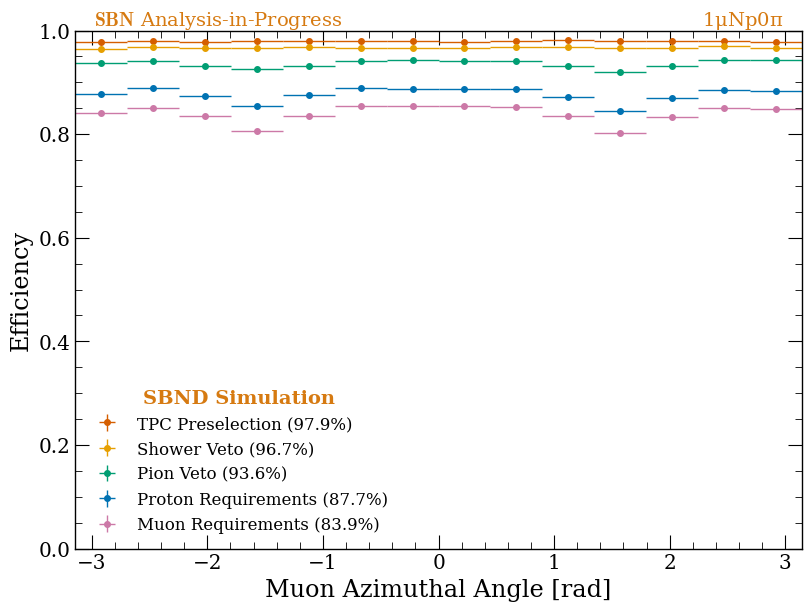

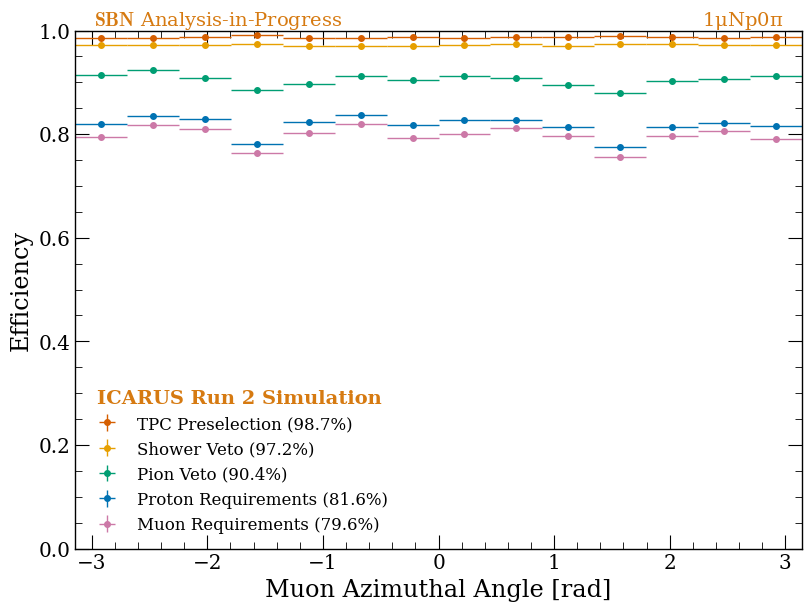

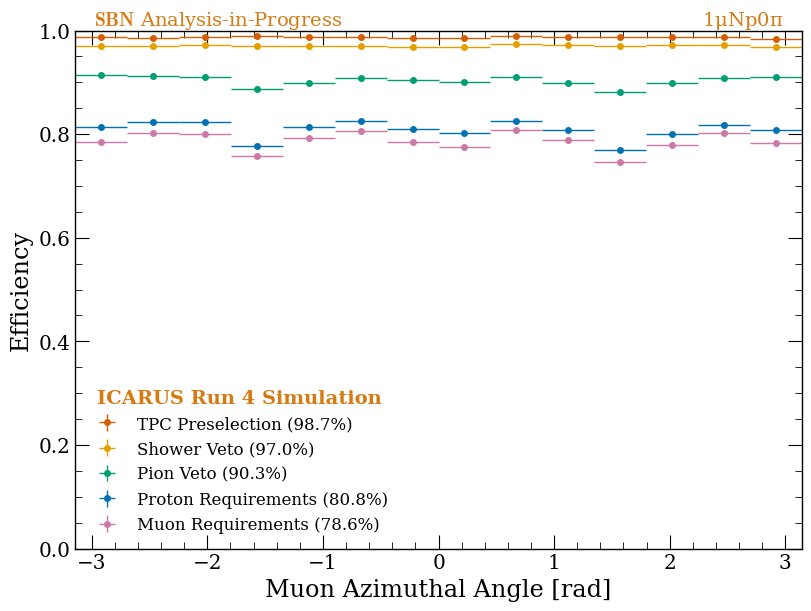

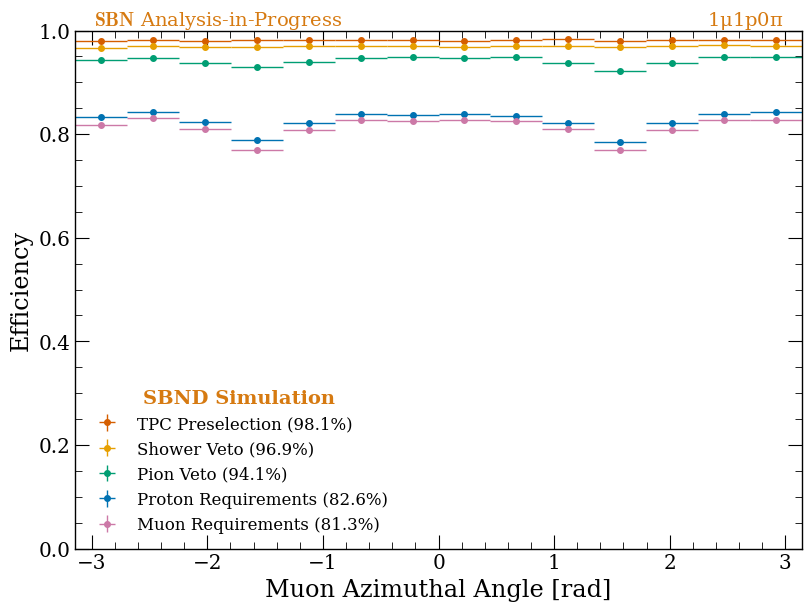

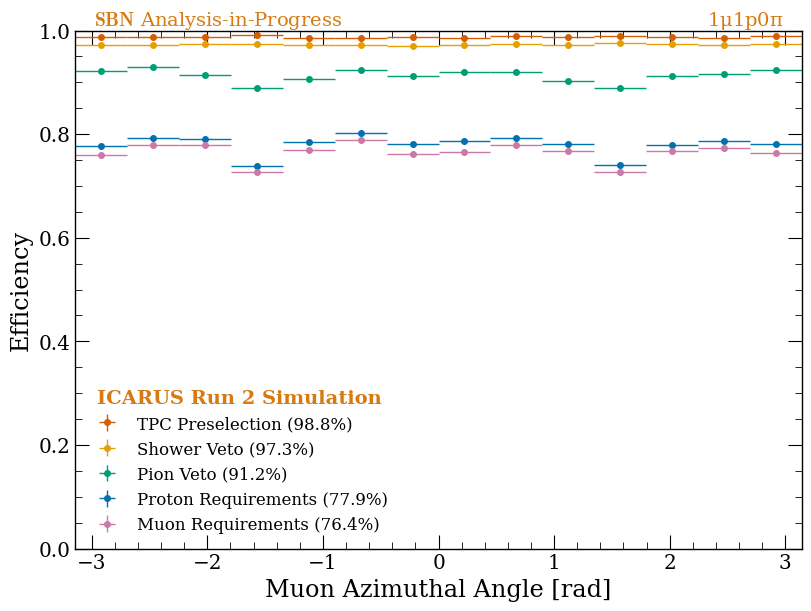

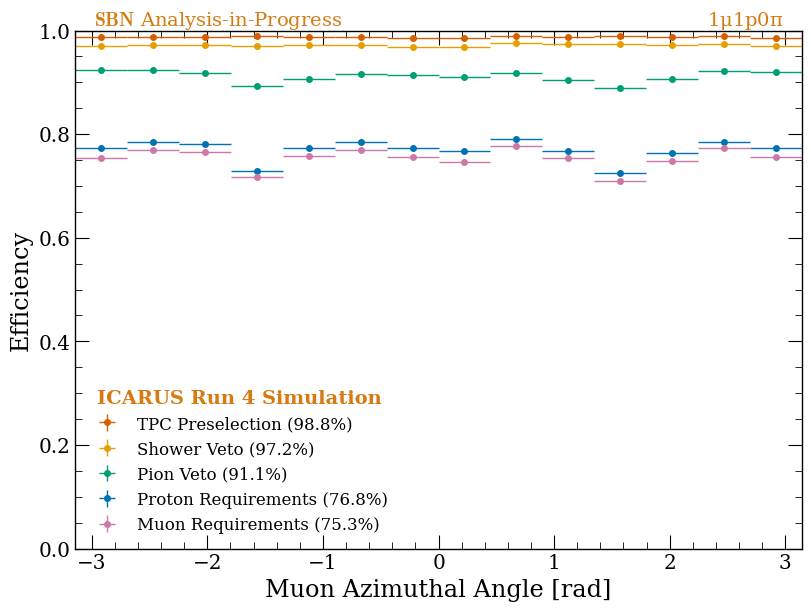

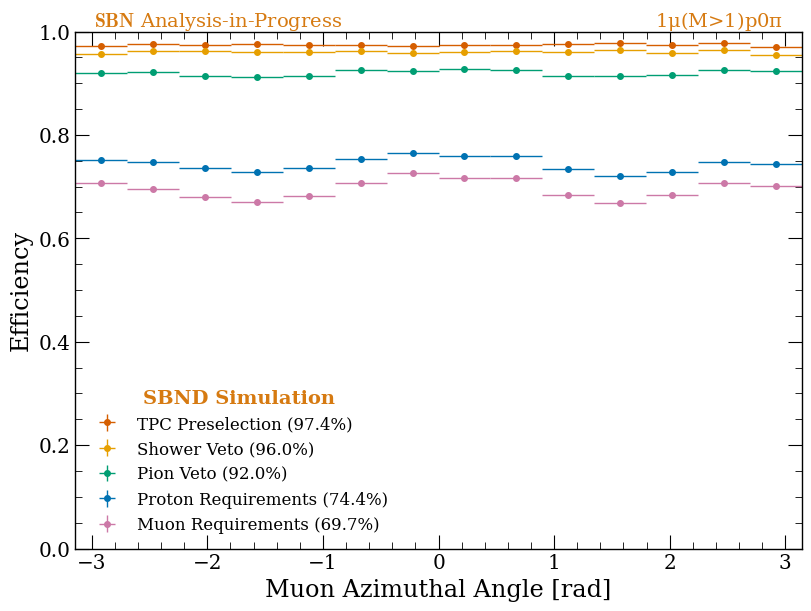

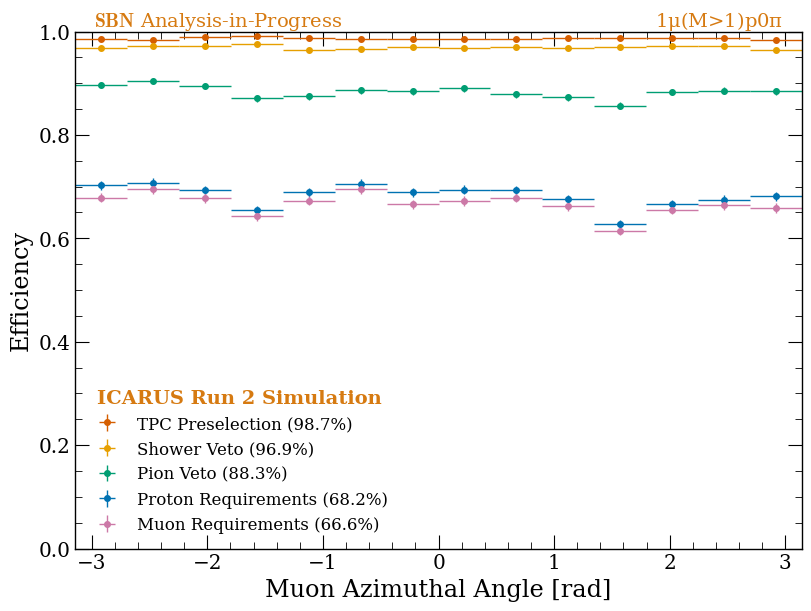

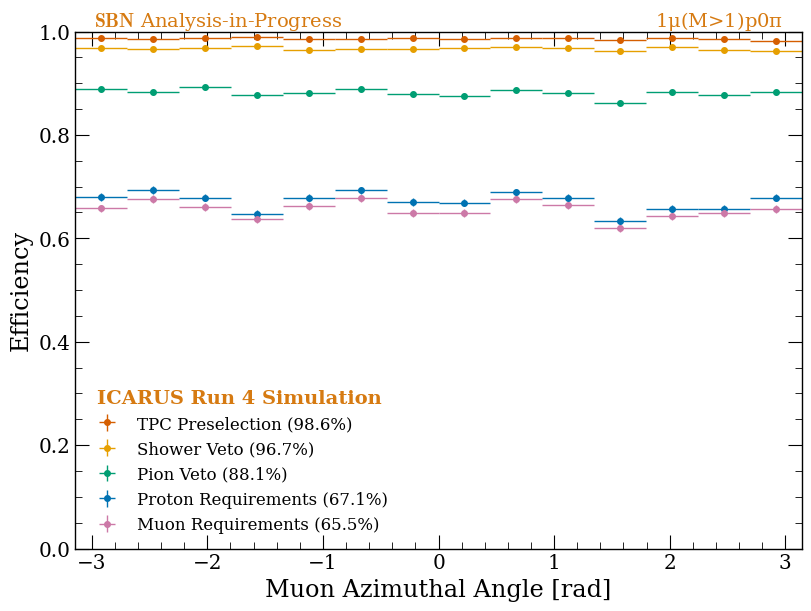

In [6]:
edges_efficiency = np.linspace(-np.pi, np.pi, 15)

for detector in DETECTOR_FILES:
    build_efficiency_plot(
        signal[detector],
        apply_signal,
        apply_proton_multiplicity,
        edges_efficiency,
        var_key='true_leading_muon_azimuthal_angle',
        xlabel='Muon Azimuthal Angle [rad]',
        detector_label=DETECTOR_TITLES[detector],
        mark_fs=r'1$\mu$Np0$\pi$',
        savefig=SAVEPATH / 'signal_and_selection' / f'efficiency_{detector}_muon_azimuthal_angle.pdf'
    )

for detector in DETECTOR_FILES:
    build_efficiency_plot(
        signal[detector],
        apply_signal_ccqe,
        apply_proton_multiplicity_1p,
        edges_efficiency,
        var_key='true_leading_muon_azimuthal_angle',
        xlabel='Muon Azimuthal Angle [rad]',
        detector_label=DETECTOR_TITLES[detector],
        mark_fs=r'1$\mu$1p0$\pi$',
        savefig=SAVEPATH / 'signal_and_selection' / f'efficiency_{detector}_muon_azimuthal_angle_singlep.pdf'
    )

for detector in DETECTOR_FILES:
    build_efficiency_plot(
        signal[detector],
        apply_signal_nproton,
        apply_proton_multiplicity_multip,
        edges_efficiency,
        var_key='true_leading_muon_azimuthal_angle',
        xlabel='Muon Azimuthal Angle [rad]',
        detector_label=DETECTOR_TITLES[detector],
        mark_fs=r'1$\mu$(M>1)p0$\pi$',
        savefig=SAVEPATH / 'signal_and_selection' / f'efficiency_{detector}_muon_azimuthal_angle_multip.pdf'
    )

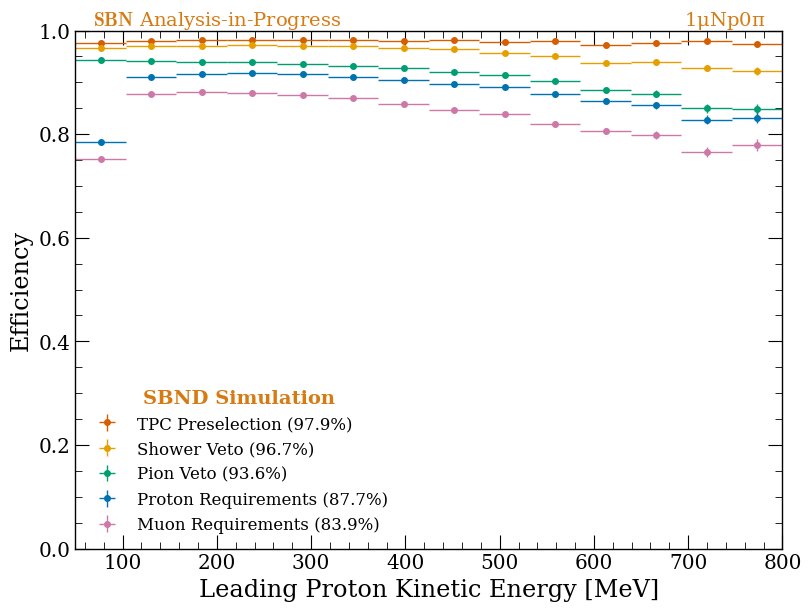

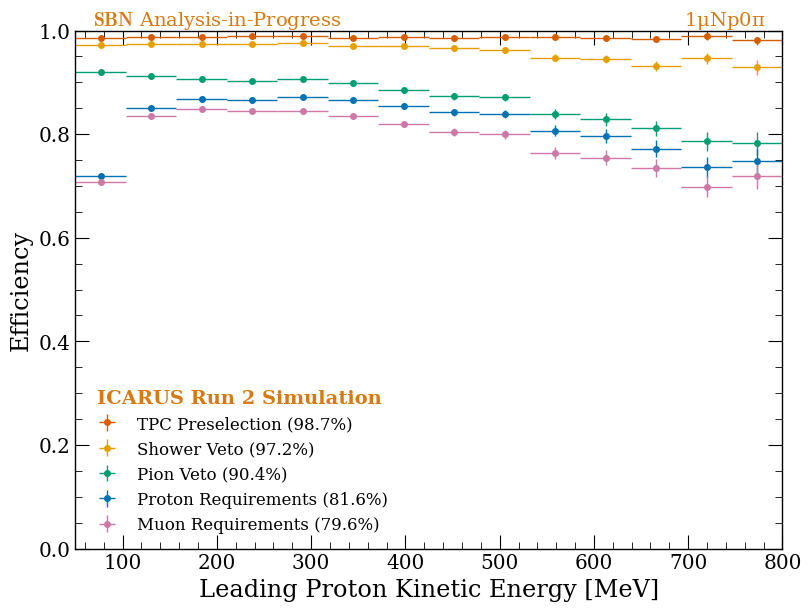

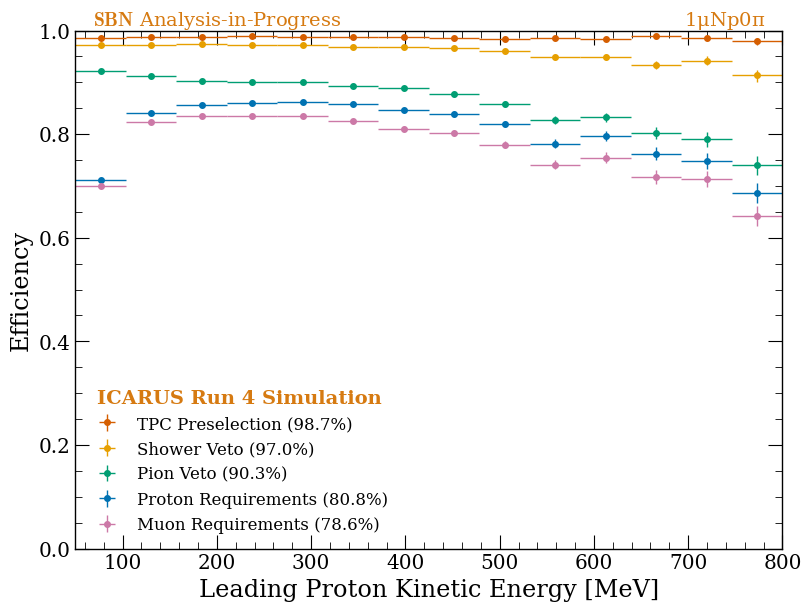

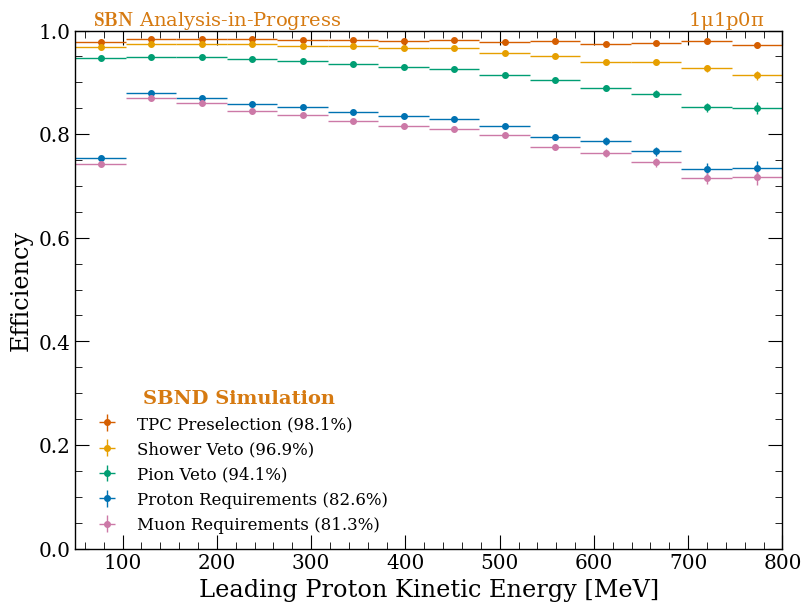

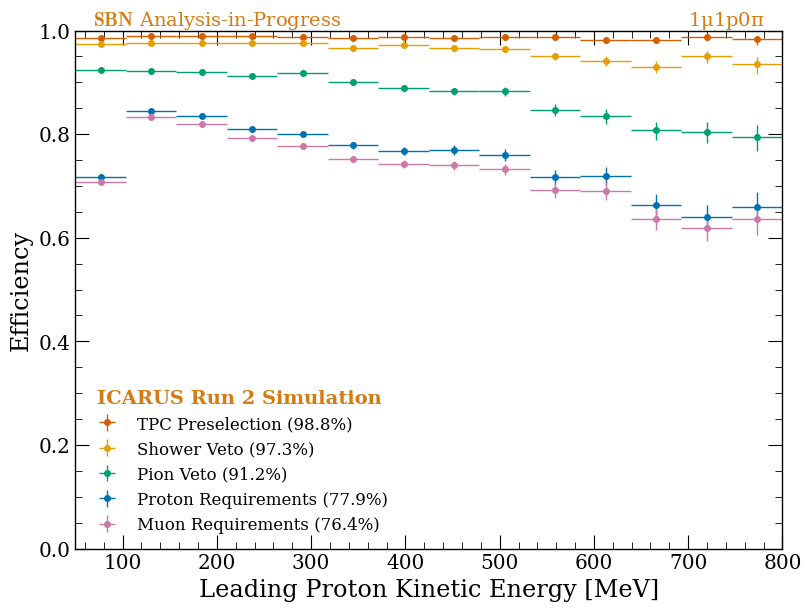

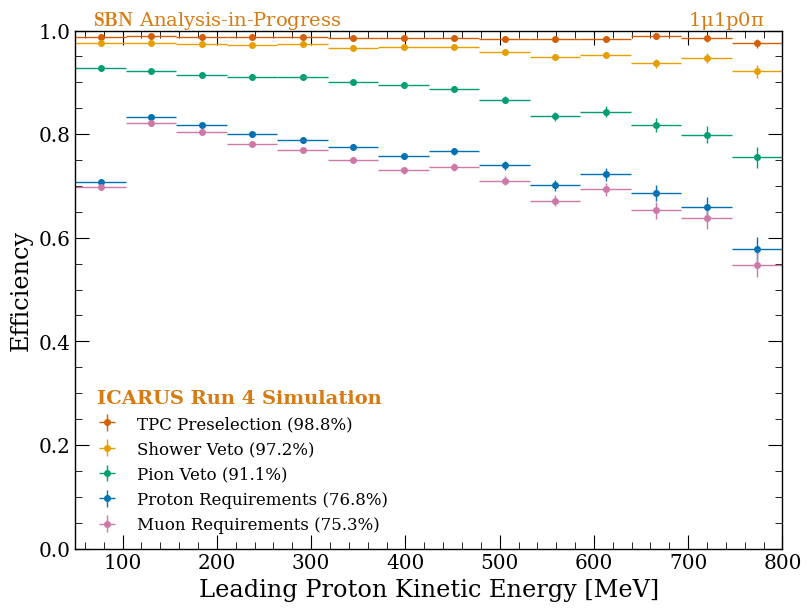

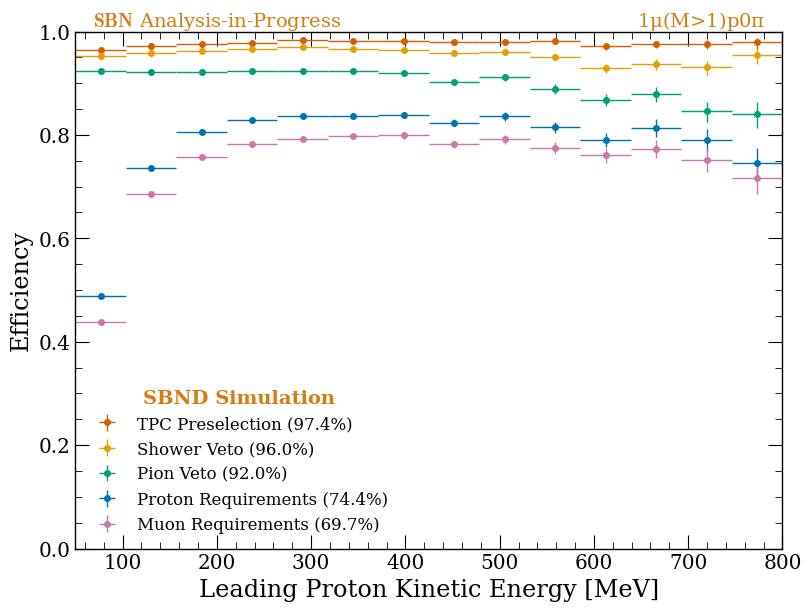

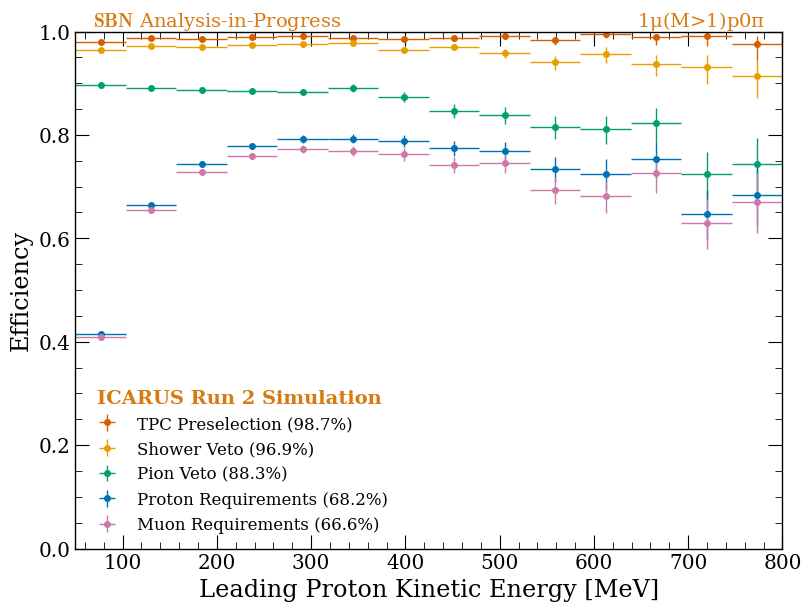

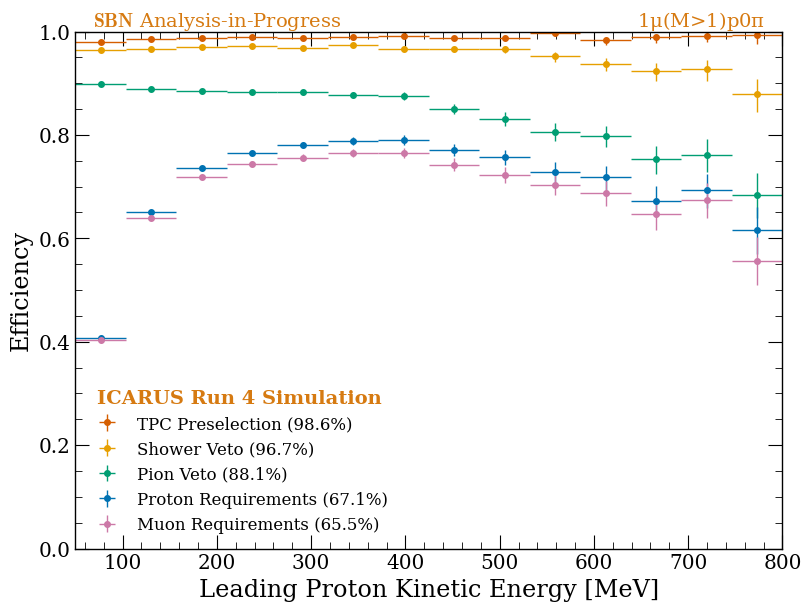

In [7]:
edges_efficiency = np.linspace(50, 800, 15)

for detector in DETECTOR_FILES:
    build_efficiency_plot(
        signal[detector],
        apply_signal,
        apply_proton_multiplicity,
        edges_efficiency,
        var_key='true_leading_proton_ke',
        xlabel='Leading Proton Kinetic Energy [MeV]',
        detector_label=DETECTOR_TITLES[detector],
        mark_fs=r'1$\mu$Np0$\pi$',
        savefig=SAVEPATH / 'signal_and_selection' / f'efficiency_{detector}_proton_ke.pdf'
    )

for detector in DETECTOR_FILES:
    build_efficiency_plot(
        signal[detector],
        apply_signal_ccqe,
        apply_proton_multiplicity_1p,
        edges_efficiency,
        var_key='true_leading_proton_ke',
        xlabel='Leading Proton Kinetic Energy [MeV]',
        detector_label=DETECTOR_TITLES[detector],
        mark_fs=r'1$\mu$1p0$\pi$',
        savefig=SAVEPATH / 'signal_and_selection' / f'efficiency_{detector}_proton_ke_singlep.pdf'
    )

for detector in DETECTOR_FILES:
    build_efficiency_plot(
        signal[detector],
        apply_signal_nproton,
        apply_proton_multiplicity_multip,
        edges_efficiency,
        var_key='true_leading_proton_ke',
        xlabel='Leading Proton Kinetic Energy [MeV]',
        detector_label=DETECTOR_TITLES[detector],
        mark_fs=r'1$\mu$(M>1)p0$\pi$',
        savefig=SAVEPATH / 'signal_and_selection' / f'efficiency_{detector}_proton_ke_multip.pdf'
    )

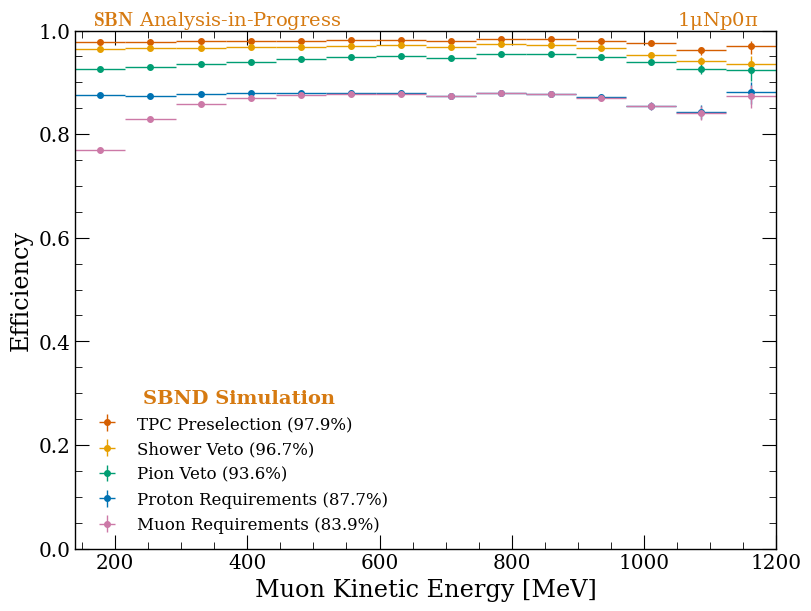

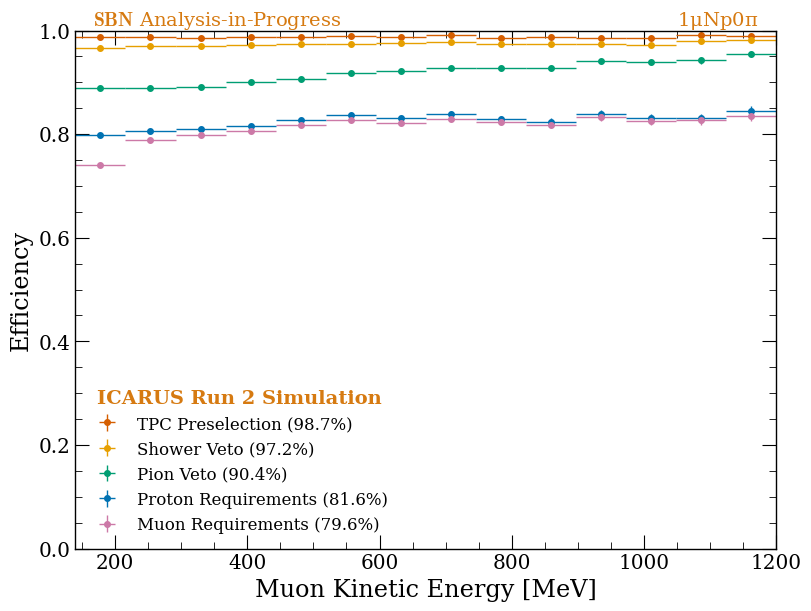

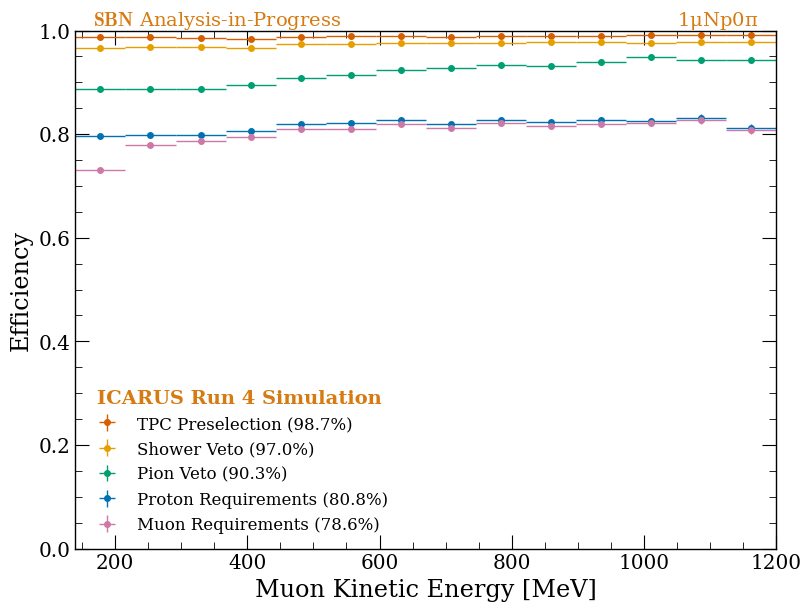

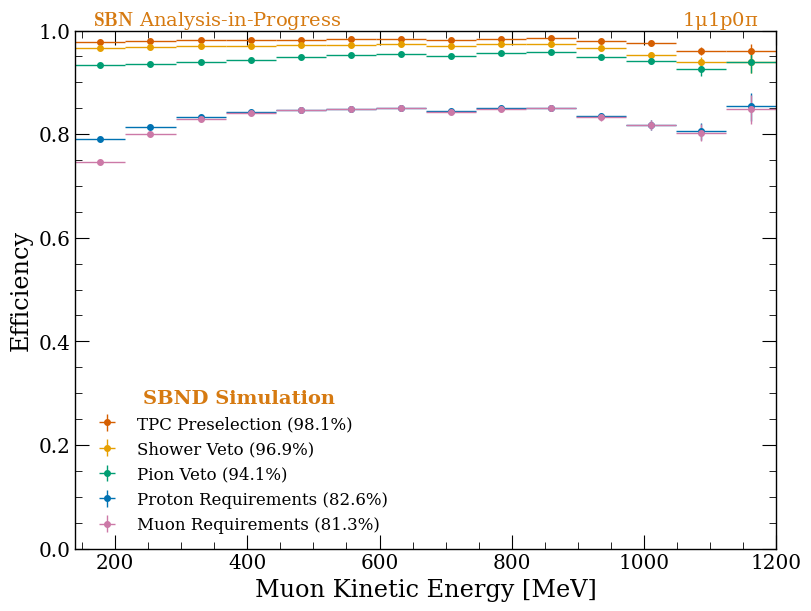

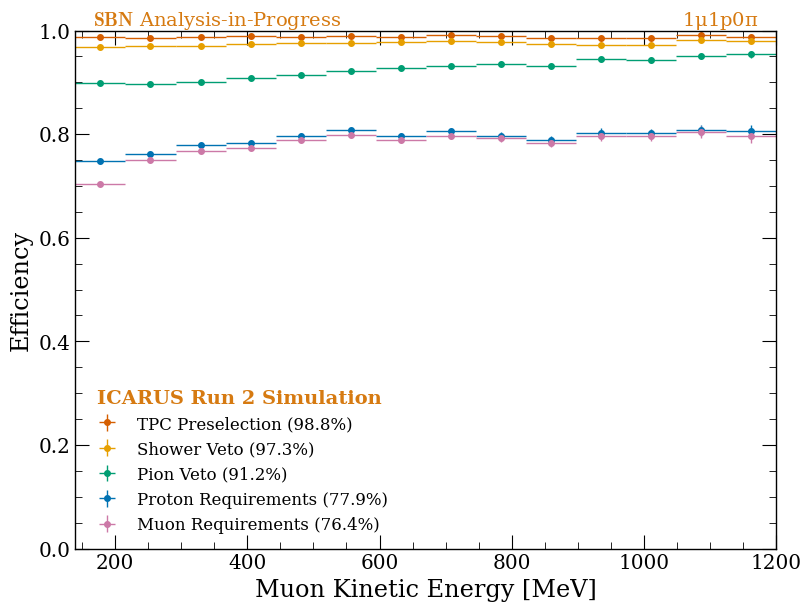

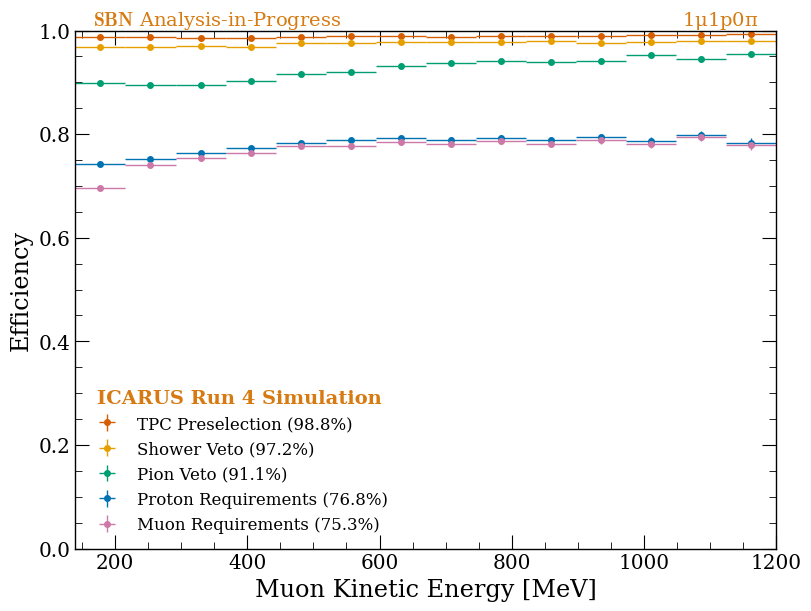

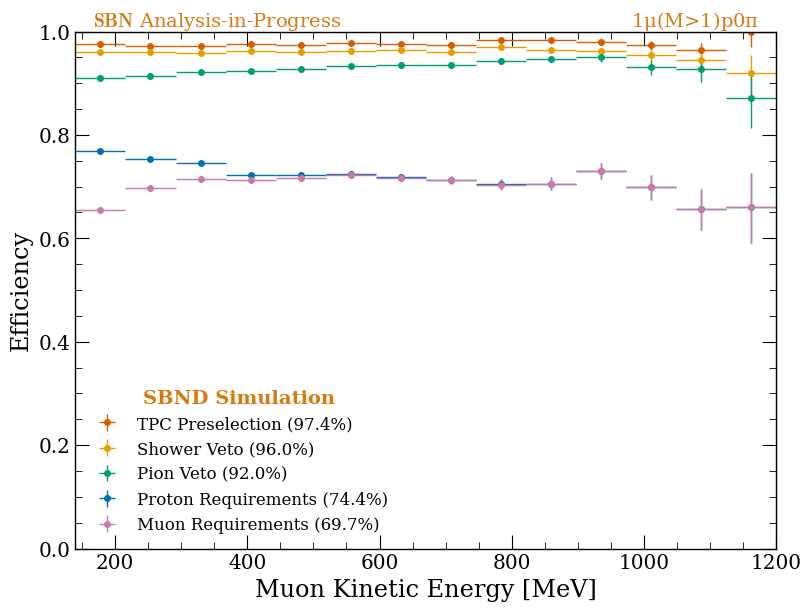

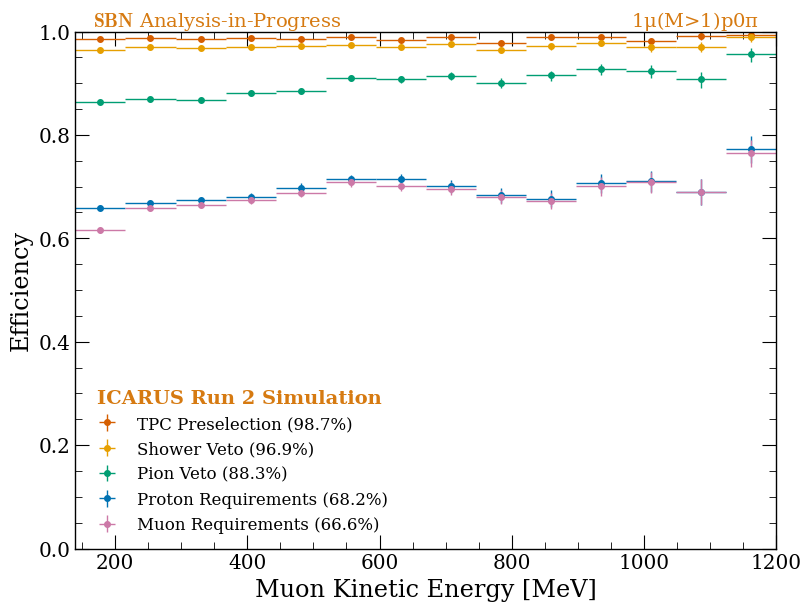

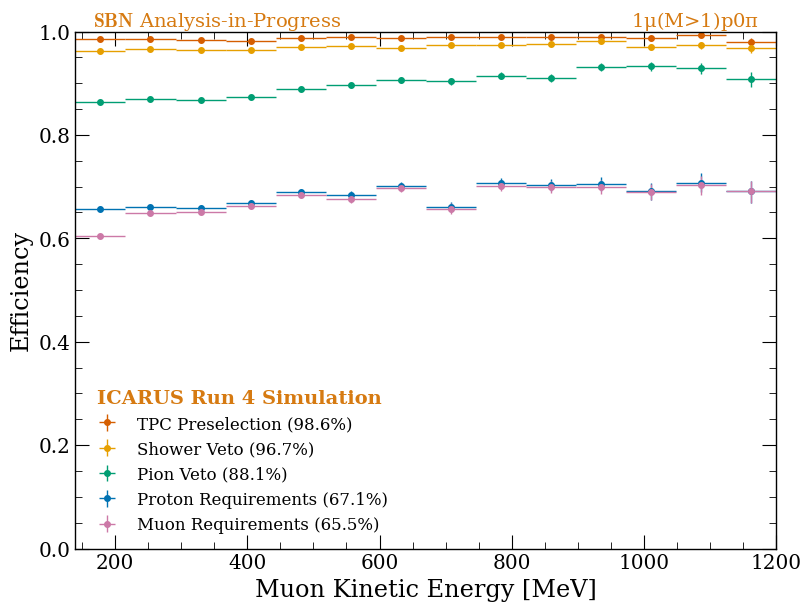

In [8]:
edges_efficiency = np.linspace(140, 1200, 15)

for detector in DETECTOR_FILES:
    build_efficiency_plot(
        signal[detector],
        apply_signal,
        apply_proton_multiplicity,
        edges_efficiency,
        var_key='true_leading_muon_ke',
        xlabel='Muon Kinetic Energy [MeV]',
        detector_label=DETECTOR_TITLES[detector],
        mark_fs=r'1$\mu$Np0$\pi$',
        savefig=SAVEPATH / 'signal_and_selection' / f'efficiency_{detector}_muon_ke.pdf'
    )

for detector in DETECTOR_FILES:
    build_efficiency_plot(
        signal[detector],
        apply_signal_ccqe,
        apply_proton_multiplicity_1p,
        edges_efficiency,
        var_key='true_leading_muon_ke',
        xlabel='Muon Kinetic Energy [MeV]',
        detector_label=DETECTOR_TITLES[detector],
        mark_fs=r'1$\mu$1p0$\pi$',
        savefig=SAVEPATH / 'signal_and_selection' / f'efficiency_{detector}_muon_ke_singlep.pdf'
    )

for detector in DETECTOR_FILES:
    build_efficiency_plot(
        signal[detector],
        apply_signal_nproton,
        apply_proton_multiplicity_multip,
        edges_efficiency,
        var_key='true_leading_muon_ke',
        xlabel='Muon Kinetic Energy [MeV]',
        detector_label=DETECTOR_TITLES[detector],
        mark_fs=r'1$\mu$(M>1)p0$\pi$',
        savefig=SAVEPATH / 'signal_and_selection' / f'efficiency_{detector}_muon_ke_multip.pdf'
    )